<a href="https://colab.research.google.com/github/ZackyRioOrlando/Praktikum-Pembelajaran-Mesin-/blob/main/JS06/JS06_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🌃
Lab 5

Klasifikasi Citra Siang dan Malam

Langkah 0 - Import Library

In [ ]:
	# Import Required Libraries
	from pathlib import Path
	import matplotlib.image as mpimg
	import matplotlib.pyplot as plt
	import cv2
	import random
	import numpy as np
	import pandas as pd

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
	# Image directories
train_dir = "/content/drive/MyDrive/images/images/training/"
test_dir = "/content/drive/MyDrive/images/images/test/"

Langkah 1 - Load Data dan Visualisasikan

In [15]:
	def load_dataset(img_dir):
	    p = Path(img_dir)
	    dirs = p.glob('*')

	    img_list = []

	    for dir in dirs:
	        label = str(dir).split('/')[-1]
	        for file in dir.glob('*.jpg'):
	            img = mpimg.imread(file)

	            if not img is None:
	                img_list.append((img, label))

	    return img_list

In [16]:
	# Load training data
	train_img = load_dataset(train_dir)

In [17]:
	# Check the first data
	# It should be a tuple consist of arrays of image and image labels
	train_img[0]

(array([[[151, 159, 162],
         [150, 158, 161],
         [148, 156, 159],
         ...,
         [ 37,  42,  46],
         [ 39,  44,  48],
         [ 40,  45,  49]],
 
        [[151, 159, 162],
         [151, 159, 162],
         [150, 158, 161],
         ...,
         [ 29,  34,  38],
         [ 29,  34,  38],
         [ 36,  41,  45]],
 
        [[152, 160, 163],
         [152, 160, 163],
         [152, 160, 163],
         ...,
         [ 31,  36,  40],
         [ 32,  37,  41],
         [ 37,  42,  46]],
 
        ...,
 
        [[  1,   1,   1],
         [  1,   1,   1],
         [  1,   1,   1],
         ...,
         [ 19,  14,  10],
         [ 19,  14,  10],
         [ 20,  15,  11]],
 
        [[  1,   1,   1],
         [  1,   1,   1],
         [  1,   1,   1],
         ...,
         [ 12,   7,   3],
         [ 13,   8,   4],
         [ 19,  14,  10]],
 
        [[  1,   1,   1],
         [  1,   1,   1],
         [  1,   1,   1],
         ...,
         [  8,   3,   0],
  

In [18]:
	# Random size checking
	pick_random = np.random.randint(0, len(train_img))

	# Check img size
	print(f'Image {pick_random}')
	print(train_img[pick_random][0].shape)

Image 36
(469, 640, 3)


In [19]:
	# Function to Visualize
	def random_img_viz(img_list):
	    rand_num = np.random.randint(0, len(img_list))

	    img = img_list[rand_num][0]
	    label = img_list[rand_num][1]
	    label_str = 'day' if label == 1 else 'night'

	    plt.imshow(img)
	    print(f'Shape\t: {img.shape}')
	    print(f'Label\t: {label}')

Shape	: (469, 640, 3)
Label	: night


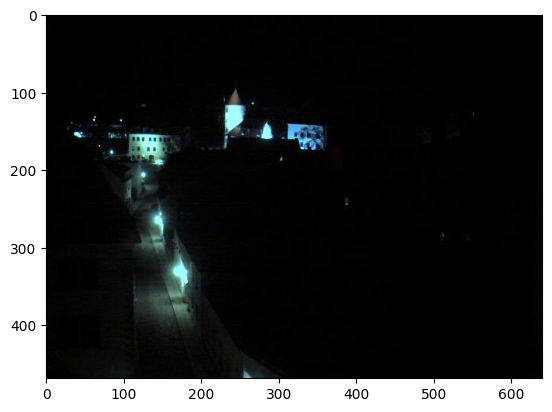

In [20]:
random_img_viz(train_img)

Langkah 3 - Pra Pengolahan Data

fungsi berikut untuk menstandarkan ukuran gambar.

In [21]:
	def standarized_input(image):
	    # resize to w: 1100, h:600
	    std_img = cv2.resize(image, (1100,600))

	    return std_img

fungsi untuk kebutuhan encoding label.

In [22]:
	def label_encoder(label):
	    # Encode the label
	    # day as 1; night as 0
	    num_val = 0

	    if(label == 'day'):
	        num_val = 1

	    return num_val

 fungsi untuk melakukan kedua hal tersebut secara sekaligus untuk semua gambar dalam list.

In [23]:
	def preprocess(img_list):
	    std_img_list = []

	    for item in img_list:
	        image = item[0]
	        label = item[1]

	        # Standarized the image
	        std_img = standarized_input(image)

	        # Create the label
	        img_label = label_encoder(label)

	        std_img_list.append((std_img, img_label))

	    return std_img_list

Lakukan pra pengolahan data pada data training.

In [24]:
train_std_img_list = preprocess(train_img)

Lakukan pengecekan ukuran gambar secara acak.

In [25]:
	# Random size checking
	pick_random = np.random.randint(0, len(train_std_img_list))

	# Check img size
	print(f'Image {pick_random}')
	print(train_std_img_list[pick_random][0].shape)

Image 113
(600, 1100, 3)


Langkah 4 - Ekstraksi Fitur

 fungsi berikut untuk mendapatkan nilai rata-rata tingkat kecerahan.

In [26]:
	# Get feature based on average brightness using HSV colorspace
	def avg_brightness(image):
	    # Convert image to HSV
	    img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

	    # Calculate the avg of brightness
	    sum_brightness = np.sum(img_hsv[:,:,2]) # take the 3rb value which is the V channel
	    area = image.shape[0] * image.shape[1]
	    avg = sum_brightness / area

	    return avg

Lakukan pengecekan pada gambar secara acak

Image 213
Avg Brighness: 192.9079


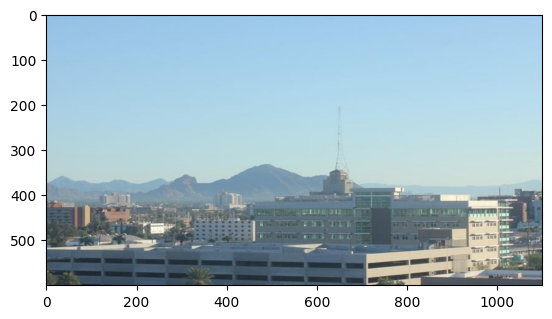

In [27]:
	# Check on random image
	rand_img = np.random.randint(0, len(train_std_img_list))

	feature_img = train_std_img_list[rand_img][0]

	avg_img = avg_brightness(feature_img)

	print(f'Image {rand_img}')
	print(f'Avg Brighness: {avg_img:.4f}')
	plt.imshow(feature_img)

Langkah 5 - Klasifikasi dengan Metode Threshold

In [28]:
	def predict_label(img, threshold):
	    # Computer average brightness
	    avg = avg_brightness(img)
	    pred = 0

	    # Predict the label based on user defined threshold
	    if avg > threshold:
	        pred = 1

	    return pred


Lakukan pengecekan prediksi secara acak pada data training

Image 104
Actual label: 0
Predicted label: 0


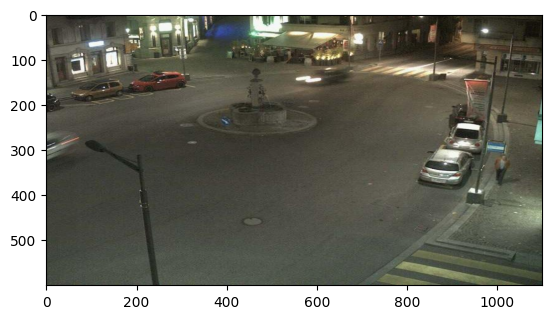

In [29]:
	# Test the classifier on train data
	rand_img = np.random.randint(0, len(train_std_img_list))

	pred = predict_label(train_std_img_list[rand_img][0], threshold=120)

	# Evaluate
	print(f'Image {rand_img}')
	print(f'Actual label: {train_std_img_list[rand_img][1]}')
	print(f'Predicted label: {pred}')
	plt.imshow(train_std_img_list[rand_img][0])

Langkah 6 - Evaluasi Manual

In [30]:
	def evaluate(img_list, threshold):
	    miss_labels = []

	    for file in img_list:
	        # Get the ground truth / correct label
	        img = file[0]
	        label = file[1]

	        # Get prediction
	        pred_label = predict_label(img, threshold)

	        # Compare ground truth and pred
	        if pred_label != label:
	            miss_labels.append((img, pred_label, label))

	    total_img = len(img_list)
	    corr_pred = total_img - len(miss_labels)
	    accuracy = corr_pred / total_img

	    print(f'Accuracy: {accuracy:.4f}')

Lakukan evaluasi pada data training dengan nilai ambang batas 120.

In [31]:
	# Evaluate on train data
	evaluate(train_std_img_list, threshold=120)

Accuracy: 0.8417


Selanjutnya, kita akan melakukan evaluasi pada data testing. Namun sebelumnya, data testing harus diperlakukan sama dengan data training dalam konteks pra progolahan data dan ekstraksi fitur.

In [32]:
	# Evaluate on test data

	# Load test data
	test_img = load_dataset(test_dir)

	# Preprocess
	test_std_img_list = preprocess(test_img)

	# Predict
	evaluate(test_std_img_list, threshold=120)

Accuracy: 0.8688


Klasifikasi dengan SVM
Sebelumnya, kita hanya menggunakan threshold sebagai acuan. Cara ini mungkin tidak efektif dikarenakan kita harus menentukan threshold dengan tepat. Oleh karena itu, selanjutnya kita akan mencoba menggunakan model SVM untuk proses klasifikasi. Seluruh langkah yang digunakan serupa, kita hanya mengubah mulai langkah ke-4.

Langkah 4 Alternatif - Membuat Feature Vectors.

In [33]:
	# Create function to extract feature for every images and stored in tabular data
	# Stored in Pandas dataframe
	def extract_avg_bright_feature(img_list):
	    avg_list = []
	    labels = []

	    for img in img_list:
	        img_avg = avg_brightness(img[0]) # Get the avg brightness from image
	        img_label = img[1] # Get the image label

	        avg_list.append(img_avg)
	        labels.append(img_label)

	    # Stack data in columcular way
	    data = np.column_stack((avg_list, labels))
	    # Create a Pandas dataframe
	    df = pd.DataFrame(data, columns=['AVG_BRIGHT', 'LABELS'])

	    return df

Cek hasilnya pada data training,

In [34]:
	# Extract feature on train data
	train_avg_img = extract_avg_bright_feature(train_std_img_list)
	print(f'Shape: {train_avg_img.shape}')
	train_avg_img.head()

Shape: (240, 2)


,AVG_BRIGHT,LABELS
0,54.999277,0.0
1,110.350603,0.0
2,88.722748,0.0
3,29.425348,0.0
4,113.001189,0.0


Lakukan langkah yang serupa pada data testing

In [35]:
	# Do the same thing on test data
	test_avg_img = extract_avg_bright_feature(test_std_img_list)
	print(f'Shape: {test_avg_img.shape}')
	test_avg_img.head()

Shape: (160, 2)


,AVG_BRIGHT,LABELS
0,94.067308,0.0
1,41.211485,0.0
2,91.099126,0.0
3,13.228938,0.0
4,26.058821,0.0


Langkah 5 - Buat Model SVM

In [36]:
	# import requied library
	from sklearn.svm import SVC

	# Split data and label
	X_train = train_avg_img.iloc[:,0].values.reshape(-1,1)
	y_train = train_avg_img.iloc[:,1]
	X_test = test_avg_img.iloc[:,0].values.reshape(-1,1)
	y_test = test_avg_img.iloc[:,1]

	model = SVC()
	model.fit(X_train, y_train)

SVC()

Langkah 6 - Evaluasi

In [37]:
	from sklearn.metrics import accuracy_score

	# Make a prediction on train data
	y_train_pred = model.predict(X_train)

	# Get the accuracy on train data
	acc_train = accuracy_score(y_train, y_train_pred)

	# Make a prediction on test data
	y_test_pred = model.predict(X_test)

	# Get the accuracy on test data
	acc_test = accuracy_score(y_test, y_test_pred)

	# Print Eval Result
	print(f'Accuracy on train: {acc_train}')
	print(f'Accuracy on test: {acc_test}')

Accuracy on train: 0.8583333333333333
Accuracy on test: 0.9
